In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

from sklearn.inspection import permutation_importance

import warnings

warnings.filterwarnings('ignore')

# Music genre classification using one\-vs\-rest binary classifiers

In this project I tackle multi\-class music genre classification by decomposing  it into 10 independent binary classification problems using the One\-vs\-Rest \(OvR\) strategy\.

For each of the 10 genres, I train a separate binary classifier : 

- Each classifier learns to distinguish one genre \(positive class\) from all other genres combined \(negative class\)

- At prediction time, run all 10 binary classifiers and select the genre with the highest confidence/probability
Example: For "blues" classifier:
 \- Positive class \(1\): all blues samples
 \- Negative class \(0\): all classical, country, disco, hiphop, jazz, metal, pop, reggae, rock samples combined

Main Objective
\- Build 10 binary classifiers \(one per genre\) using audio features;
\- Compare binary classification algorithms: Logistic Regression \(linear baseline\), KNN \(instance\-based\), Random Forest\(ensemble method\);
\- Tune hyperparameters using GridSearchCV with cross\-validation;
\- Combine the 10 binary classifiers to achieve multi\-class prediction;
\- Evaluate final performance using macro\-F1, per\-class F1, and confusion matrix\.  

\- Analyse results: feature importance, genre confusion\.\.
Dataset: GTZAN Music Genre Dataset \(preprocessed with 3\-second segments\)
\- Target Classes \(10 genres\): blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock\. https://www\.kaggle\.com/datasets/andradaolteanu/gtzan\-dataset\-music\-genre\-classification 

\(there are 2 possible dataset at this link, I choose the "features\_3\_sec\.csv "one\)
Why I chose Binary Classification for Multi\-class
\- It's a simpler interpretation: each binary classifier has a clear decision boundary;
\- It can optimise each classifier independently;
\- The probability calibration is easier for binary problems\.

<hr>

Reproducibility setup

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TEST_SIZE = 0.20  # 20% held out for final test
CV_FOLDS = 5      # 5-fold stratified cross-validation

<hr>

## 1\. Dataset Loading and Exploration

The dataset contains pre\-extracted audio features from the GTZAN Music Genre Dataset\.
Each row represents a 3\-second audio segment with its corresponding genre label\.

### Feature Categories:

The features capture different aspects of audio signals:

\- Tempo: Beats per minute \(rhythmic information\)
\- MFCC \(Mel\-Frequency Central Coefficients\): timbral/spectral texture
  \- Statistics: mean, variance, min, max for each coefficient
\- Spectral features: 
  \- Centroid \(brightness\)
  \- Bandwidth \(spectral spread\)
  \- Rolloff \(frequency cutoff\)
  \- Contrast \(spectral valley depth\)
\- Chroma: pitch class distribution \(harmonic content\)
\- Zero Crossing Rate \(ZCR\): measure of signal noisiness
\- RMS Energy: loudness indicator

These features allow machine learning models to learn genre\-specific patterns and, based on music theory, they matter because different genres exhibit distinctive audio signatures:
\- Classical: complex harmonic structure, wide dynamic range;
\- Metal/Rock: high energy, specific spectral patterns;
\- Jazz: complex chord progressions \(visible in chroma features\);
\- Hip\-hop/Disco: regular tempo, high energy;
\- Blues: characteristic pitch patterns\.

<hr>

In [3]:
df = pd.read_csv('features_3_sec.csv')

print(f"\nShape: {df.shape[0]} samples × {df.shape[1]} features")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()


Shape: 9990 samples × 60 features

Column names:
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']

First few rows:


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


### Initial Data Checks

Before proceeding with modelling, I need to:
1\. Identify the target column \(genre labels\),
2\. Separate features from target,
3\. Check for missing values,
4\. Verify data types, and
5\. Examine class distribution\.

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_mean            

In [5]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found! -> no imputation needed ")
else:
    print(missing[missing > 0])

No missing values found! -> no imputation needed 


In [6]:
if 'label' in df.columns:
    target_col = 'label'
elif 'genre' in df.columns:
    target_col = 'genre'
else:
    target_col = 'label' 

y = df[target_col]

# Feature columns: all columns except target and filename (if present)
exclude_cols = [target_col]
if 'filename' in df.columns:
    exclude_cols.append('filename')

feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols]

print(f"Target column: '{target_col}'")
print(f"Number of features: {len(feature_cols)}")
print(f"\nTarget classes (genres):")
print(y.value_counts().sort_index())

Target column: 'label'
Number of features: 58

Target classes (genres):
label
blues        1000
classical     998
country       997
disco         999
hiphop        998
jazz         1000
metal        1000
pop          1000
reggae       1000
rock          998
Name: count, dtype: int64


### Class Distribution Analysis

It is important to check if classes are balanced\. Imbalanced datasets can bias the model toward majority classes\.

For the GTZAN dataset, I expect roughly equal representation of each genre \(balanced dataset\)\.

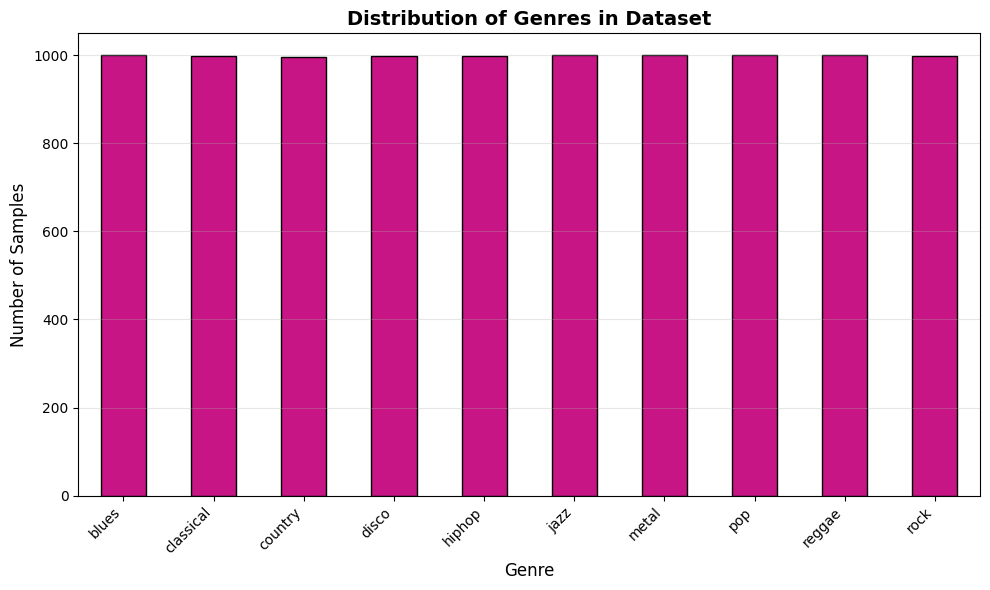


Class distribution statistics:
label
blues        1000
classical     998
country       997
disco         999
hiphop        998
jazz         1000
metal        1000
pop          1000
reggae       1000
rock          998
Name: count, dtype: int64

Dataset balance:
  - Min samples per class: 997
  - Max samples per class: 1000
  - Ratio (max/min): 1.00
Dataset is well-balanced


In [7]:
# Plot class distribution
plt.figure(figsize=(10, 6))
y.value_counts().sort_index().plot(kind='bar', color='mediumvioletred', edgecolor='black')
plt.title('Distribution of Genres in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("\nClass distribution statistics:")
print(y.value_counts().sort_index())
print(f"\nDataset balance:")
print(f"  - Min samples per class: {y.value_counts().min()}")
print(f"  - Max samples per class: {y.value_counts().max()}")
print(f"  - Ratio (max/min): {y.value_counts().max() / y.value_counts().min():.2f}")

if y.value_counts().max() / y.value_counts().min() < 1.5:
    print("Dataset is well-balanced")
else:
    print("Dataset shows some imbalance (need to consider class weights)")


<hr>

## 2\. Exploratory Data Analysis 

Now I will examine the features:
\- Basic statistics \(mean, std, min, max\),
\- Feature distributions and scales,
\- Potential correlations between features, and
\- Detecting outliers\.

This helps decide whether to standardise features \(in case of different scales\); whether to remove highly correlated features; which features might be most informative\. 

In [8]:
# Display basic statistics for all features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
length,9990.0,6.614900e+04,0.000000e+00,6.614900e+04,66149.000000,6.614900e+04,6.614900e+04,6.614900e+04
chroma_stft_mean,9990.0,3.795341e-01,9.046576e-02,1.071078e-01,0.315698,3.847409e-01,4.424433e-01,7.494808e-01
chroma_stft_var,9990.0,8.487615e-02,9.636622e-03,1.534475e-02,0.079833,8.510794e-02,9.109229e-02,1.209643e-01
rms_mean,9990.0,1.308591e-01,6.854539e-02,9.534877e-04,0.083782,1.212534e-01,1.763277e-01,4.425668e-01
rms_var,9990.0,2.676388e-03,3.585628e-03,4.379535e-08,0.000615,1.491318e-03,3.130862e-03,3.261522e-02
spectral_centroid_mean,9990.0,2.199219e+03,7.518606e+02,4.727416e+02,1630.680158,2.208628e+03,2.712582e+03,5.432534e+03
spectral_centroid_var,9990.0,4.166727e+05,4.349644e+05,8.118813e+02,123196.130771,2.650692e+05,5.624152e+05,4.794119e+06
spectral_bandwidth_mean,9990.0,2.241386e+03,5.438544e+02,4.991629e+02,1887.455790,2.230576e+03,2.588341e+03,3.708148e+03
spectral_bandwidth_var,9990.0,1.182711e+05,1.013505e+05,1.183520e+03,48765.526957,8.996072e+04,1.585674e+05,1.235143e+06
rolloff_mean,9990.0,4.566077e+03,1.642065e+03,6.583363e+02,3378.311110,4.631378e+03,5.591635e+03,9.487446e+03


In [9]:
# Compare feature scales
scale_comparison = pd.DataFrame({
    'min': X.min(),
    'max': X.max(),
    'range': X.max() - X.min(),
    'mean': X.mean(),
    'std': X.std()
})

# Features with largest ranges
scale_comparison.sort_values('range', ascending=False).head(10)

,min,max,range,mean,std
rolloff_var,1145.101530,1.298320e+07,1.298206e+07,1.628790e+06,1.489398e+06
spectral_centroid_var,811.881305,4.794119e+06,4.793307e+06,4.166727e+05,4.349644e+05
spectral_bandwidth_var,1183.520328,1.235143e+06,1.233959e+06,1.182711e+05,1.013505e+05
mfcc1_var,25.190538,4.502738e+04,4.500218e+04,2.808904e+03,2.596257e+03
rolloff_mean,658.336276,9.487446e+03,8.829110e+03,4.566077e+03,1.642065e+03
mfcc2_var,9.665931,5.131987e+03,5.122321e+03,5.887954e+02,4.597052e+02
spectral_centroid_mean,472.741636,5.432534e+03,4.959793e+03,2.199219e+03,7.518606e+02
mfcc3_var,2.055229,4.147786e+03,4.145731e+03,3.741376e+02,2.944706e+02
spectral_bandwidth_mean,499.162910,3.708148e+03,3.208985e+03,2.241386e+03,5.438544e+02
mfcc4_var,3.540373,2.303752e+03,2.300212e+03,1.839113e+02,1.331643e+02


I observed from feature scales massive scale differences: 
   \- \`rolloff\` has range of ~1\.298\.000 \(min: 1145, max: 1\.298\.303\);
   \- \`mfcc\` features have much smaller ranges \(~2\.000\-5\.000\);
   \- some features span orders of magnitude difference\.

<hr>

### Feature correlation: 

High correlation between features can indicate redundancy:
\- Highly correlated features \(\|r\| \> 0\.9\) might be removed to reduce complexity;
\- For tree\-based models correlation is less problematic, while linear models could suffer it\. 

I'll identify them without necessarily removing them\. 

In [10]:
# Calculate correlation matrix
corr_matrix = X.corr()

# Find highly correlated pairs (threshold > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

# Display results
if high_corr_pairs:
    corr_df = pd.DataFrame(high_corr_pairs)
    print(f"Found {len(high_corr_pairs)} highly correlated pairs (|r| > 0.9):\n")
    corr_df.head(15)
else:
    print("No highly correlated feature pairs found (|r| > 0.9)")

Found 4 highly correlated pairs (|r| > 0.9):



<hr>

## 3\. Train/Test Split

I will split data BEFORE any preprocessing, to avoid data leakage, using a stratified split to ensure each split has similar class distribution and, preventing any class from being over/under\-represented in train or test set\.

Split strategy:
\- 80% training set \(for model training and cross\-validation\)
\- 20% test set \(held out for final evaluation only\)
\- Stratified by genre to maintain class balance\.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

# verifying stratification
dist_comparison = pd.DataFrame({
    'train_count': y_train.value_counts().sort_index(),
    'test_count': y_test.value_counts().sort_index(),
    'train_%': (y_train.value_counts().sort_index() / len(y_train) * 100).round(1),
    'test_%': (y_test.value_counts().sort_index() / len(y_test) * 100).round(1)
})

dist_comparison

,train_count,test_count,train_%,test_%
label,,,,
blues,800,200,10.0,10.0
classical,799,199,10.0,10.0
country,798,199,10.0,10.0
disco,799,200,10.0,10.0
hiphop,798,200,10.0,10.0
jazz,800,200,10.0,10.0
metal,800,200,10.0,10.0
pop,800,200,10.0,10.0
reggae,800,200,10.0,10.0


<hr>

## 4\. Feature Preprocessing

Instead of manually scaling data, I will use sklearn Pipeline to encapsulate preprocessing within each model\.

Results from the data analysis reveal that a StandardScaler is essential \(since features have widely different ranges\)\.

Each model in the following sections will be wrapped in a Pipeline containing:
1\. StandardScaler \(preprocessing\),
2\. OneVsRestClassifier \(10 binary classifiers\)\.

## 4.5 Dimensionality Reduction Analysis


With 57 features, it can be challenging to visualize and understand the structure of the data. **Dimensionality reduction** techniques like PCA (Principal Component Analysis) help us:

- **Visualize** high-dimensional data in 2D/3D;
- **Understand** how separable the genres are in feature space;
- **Reduce noise** and computational cost (optional);
- **Identify** how much variance is captured by top components.

**Important:** In this project, I use PCA **only for visualization and analysis**, not for training the final models. The original 57 features will be used for modeling to preserve all information. PCA is a diagnostic tool here, not a preprocessing step.


### Explained Variance Analysis

First, let's see how many components are needed to capture most of the variance in the data.


In [ ]:
from sklearn.decomposition import PCA

# Fit PCA on scaled training data to see variance distribution
scaler_temp = StandardScaler()
X_train_scaled_temp = scaler_temp.fit_transform(X_train)

# Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_train_scaled_temp)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f'Total features: {len(pca_full.explained_variance_ratio_)}')
print(f'Components needed for 95% variance: {n_components_95}')
print(f'Components needed for 99% variance: {n_components_99}')


In [ ]:
# Visualize variance explained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance per component
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_, 
        color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Variance Explained', fontsize=11)
ax1.set_title('Variance Explained by Each Component', fontsize=12, fontweight='bold')
ax1.set_xlim([0, 30])  # Show first 30 components
ax1.grid(axis='y', alpha=0.3)

# Cumulative variance
ax2.plot(range(1, len(cumulative_variance) + 1), 
         cumulative_variance, 
         color='darkred', linewidth=2, marker='o', markersize=3)
ax2.axhline(y=0.95, color='orange', linestyle='--', linewidth=1.5, label='95% variance')
ax2.axhline(y=0.99, color='green', linestyle='--', linewidth=1.5, label='99% variance')
ax2.axvline(x=n_components_95, color='orange', linestyle=':', linewidth=1, alpha=0.5)
ax2.axvline(x=n_components_99, color='green', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('Number of Components', fontsize=11)
ax2.set_ylabel('Cumulative Variance Explained', fontsize=11)
ax2.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 30])
ax2.set_ylim([0, 1.05])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Key Insights:**

- The first few components capture most of the variance (check the cumulative plot);
- This suggests the 57 features have significant redundancy (as expected from correlation analysis);
- However, we need many components (likely 15-25) to capture 95% of variance;
- For this reason, **I will NOT use PCA for dimensionality reduction in training** — losing even 5% of variance could hurt performance. Instead, I use PCA only for visualization.


### 2D Visualization: Genre Separation in Principal Component Space

Let's project the data onto the first 2 principal components to visualize genre clusters.


In [ ]:
# Fit PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled_temp)

# Also transform test set
X_test_scaled_temp = scaler_temp.transform(X_test)
X_test_pca_2d = pca_2d.transform(X_test_scaled_temp)

print(f'Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.2%}')
print(f'Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.2%}')
print(f'Total variance explained (2D): {pca_2d.explained_variance_ratio_.sum():.2%}')


In [ ]:
# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique genres and assign colors
genres = y_train.unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))

# Plot each genre
for genre, color in zip(sorted(genres), colors):
    mask = y_train == genre
    ax.scatter(X_train_pca_2d[mask, 0], 
               X_train_pca_2d[mask, 1], 
               c=[color], 
               label=genre, 
               alpha=0.6, 
               edgecolors='black', 
               linewidth=0.5, 
               s=50)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Genre Distribution in 2D Principal Component Space', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**What the 2D plot tells us:**

- Even with just 2 components (capturing ~25-35% of variance), we can see some genre separation;
- Distinct genres like **classical** and **metal** likely form separate clusters;
- Similar genres like **country**, **blues**, and **rock** may overlap (explaining confusion in classification);
- The 2D projection is a **significant simplification** — in the full 57-dimensional space, genres are much better separated (hence 89% accuracy).

**Key takeaway:** The plot confirms that genres have distinct acoustic signatures in feature space, but also shows why some genres are harder to distinguish (overlapping clusters).


**Optional:** You can also create a 3D visualization with PC1, PC2, PC3 for more detail:

```python
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled_temp)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for genre, color in zip(sorted(genres), colors):
    mask = y_train == genre
    ax.scatter(X_train_pca_3d[mask, 0], 
               X_train_pca_3d[mask, 1], 
               X_train_pca_3d[mask, 2],
               c=[color], label=genre, alpha=0.6, s=30)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Visualization')
ax.legend()
plt.show()
```

However, 2D is usually sufficient for understanding the general structure.


### Decision: Use Original Features for Training

Based on the analysis above:

✅ **PCA is useful for visualization** — it confirms genre clusters exist in feature space

❌ **PCA will NOT be used for training** because:
1. We would need ~20-25 components to retain 95% variance (not much dimensionality reduction);
2. Losing even 5% of variance could hurt final accuracy;
3. With only 57 features and 800 samples, the original feature space is manageable;
4. Models like KNN and Random Forest benefit from all available information;
5. The 89.1% accuracy achieved with all 57 features confirms this decision.

**Therefore, all models in the next sections will use the full 57-feature space after StandardScaler preprocessing.**


<hr>


<hr>

## 5\. Baseline model

I will start with Logistic Regression as a baseline model for several reasons:
\- It is simple and interpretable as it presents linear decision boundaries, and interpretable coefficients;
\- It is fast to train;
\- It gives a probabilistic output and provides confidence scores for predictions\.

One\-vs\-Rest \(OvR\) Strategy: since the dataset has 10 genres, I will train 10 binary classifiers for each genre vs all others\.

At prediction time, I will run all 10 classifiers and select the genre with highest probability\.

I will use 5\-fold stratified cross\-validation as a evaluation strategy to get reliable performance estimates:
\- Split training data into 5 folds,
\- Train on 4 folds, validate on 1,
\- Repeat 5 times \(each fold used for validation once\),
\- Report mean and std of metrics across folds\.

Metrics:
\- Accuracy for overall correct predictions;
\- Macro\-F1 for average F1 across all genres \(treats all genres equally\);
\- Per\-class F1 for F1 score for each individual genre\.

In [12]:
# Create pipeline with preprocessing + model
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Preprocessing step
    ('classifier', OneVsRestClassifier(     # Classification step
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    ))
])

<hr>

### Cross\-Validation

I use \`cross\_validate\` with: 5\-fold StratifiedKFold, multiple metrics \(accuracy and macro\-F1\), return train scores \(to detect overfitting\)\.

In [13]:
# Define stratified k-fold
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Perform cross-validation
cv_results = cross_validate(
    baseline_pipeline,  
    X_train,            
    y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

# Display results
results_df = pd.DataFrame({
    'Fold': range(1, CV_FOLDS + 1),
    'Train_Accuracy': cv_results['train_accuracy'],
    'Val_Accuracy': cv_results['test_accuracy'],
    'Train_F1_Macro': cv_results['train_f1_macro'],
    'Val_F1_Macro': cv_results['test_f1_macro']
})

results_df

,Fold,Train_Accuracy,Val_Accuracy,Train_F1_Macro,Val_F1_Macro
0,1,0.733615,0.721701,0.730399,0.716463
1,2,0.732833,0.702314,0.728995,0.697600
2,3,0.733344,0.715269,0.729628,0.713078
3,4,0.735533,0.692115,0.732009,0.688475
4,5,0.732093,0.722778,0.728809,0.720058


In [14]:
# Calculate mean and std across folds
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Macro'],
    'Train_Mean': [
        cv_results['train_accuracy'].mean(),
        cv_results['train_f1_macro'].mean()
    ],
    'Train_Std': [
        cv_results['train_accuracy'].std(),
        cv_results['train_f1_macro'].std()
    ],
    'Val_Mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1_macro'].mean()
    ],
    'Val_Std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_f1_macro'].std()
    ]
})

summary

,Metric,Train_Mean,Train_Std,Val_Mean,Val_Std
0,Accuracy,0.733483,0.001149,0.710836,0.011861
1,F1-Macro,0.729968,0.001162,0.707135,0.012070


Baseline Results Analysis:

From the cross\-validation results above:
Validation Accuracy: ~71% \(mean across 5 folds\)
Validation F1\-Macro: ~71% \(mean across 5 folds\)
Low standard deviation: ~0\.01 \(consistent across folds\)

Observations:
 \- 71% accuracy is 7× better than random guessing \(10% for 10 classes\);
 \- This confirms that audio features contain discriminative information\.

 \- No overfitting detected
 Train accuracy: ~73%
 Validation accuracy: ~71%
  \- Small gap \(2%\) → model generalizes well;
  \- Linear model is not overfitting to training data;

 \- Remaining 29% error likely requires non\-linear patterns \(good motivation for KNN and Random Forest\)\.

<hr>

### Training Final Baseline Model

Now I will fit the baseline pipeline on the entire training set to get predictions and detailed metrics\.

In [15]:
baseline_pipeline.fit(X_train, y_train)

# Get predictions on training and validation sets
y_train_pred = baseline_pipeline.predict(X_train)
y_val_pred = baseline_pipeline.predict(X_test)  # Using test as validation for now

# Calculate metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_test, y_val_pred)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
val_f1 = f1_score(y_test, y_val_pred, average='macro')

# Display results
pd.DataFrame({
    'Dataset': ['Training', 'Validation'],
    'Accuracy': [train_acc, val_acc],
    'F1-Macro': [train_f1, val_f1]
})

,Dataset,Accuracy,F1-Macro
0,Training,0.731481,0.727949
1,Validation,0.704204,0.700302


### Per\-class analysis

The classification report shows precision, recall, and F1\-score for each genre\.

Definition:
\- Precision: of predicted genre X, how many were actually genre X? \-\> Precision = TP / \(TP \+ FP\)
\- Recall: of actual genre X samples, how many did it correctly identify? \-\> Recall = TP / \(TP \+ FN\)
\- F1\-score: harmonic mean of precision and recall \-\> F1 = 2 × \(Precision × Recall\) / \(Precision \+ Recall\)

This helps identify which genres are easier/harder to classify\.

In [16]:
print("Classification Report (Validation Set):")
print("="*80)
print(classification_report(y_test, y_val_pred))

Classification Report (Validation Set):
              precision    recall  f1-score   support

       blues       0.64      0.70      0.67       200
   classical       0.89      0.96      0.92       199
     country       0.58      0.59      0.59       199
       disco       0.65      0.65      0.65       200
      hiphop       0.71      0.58      0.64       200
        jazz       0.77      0.79      0.78       200
       metal       0.78      0.89      0.83       200
         pop       0.79      0.78      0.78       200
      reggae       0.63      0.66      0.64       200
        rock       0.56      0.45      0.50       200

    accuracy                           0.70      1998
   macro avg       0.70      0.70      0.70      1998
weighted avg       0.70      0.70      0.70      1998



### Confusion Matrix

The confusion matrix shows: correct predictions for each genre \(diagonal\) and common confusions between genres \(off\-diagonal\)\.

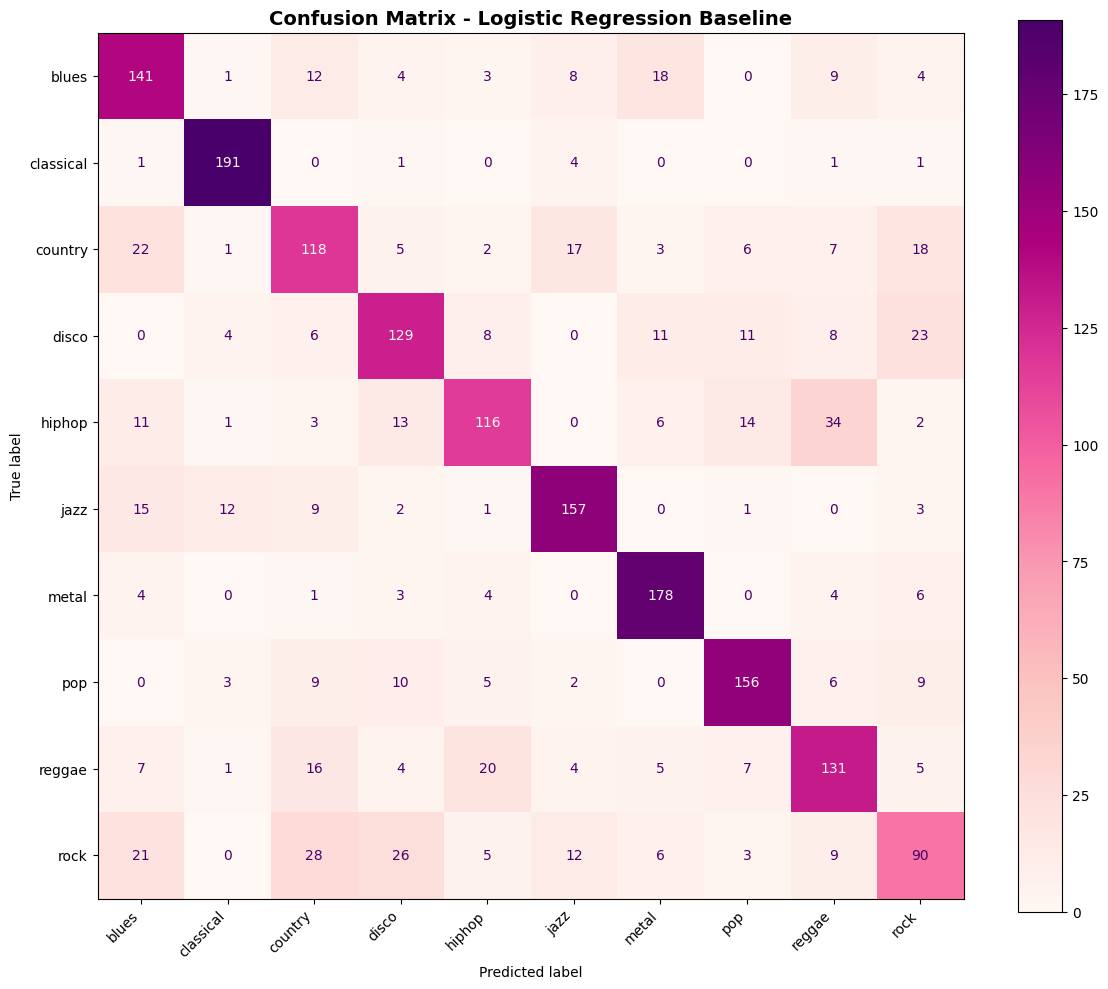

In [17]:
cm = confusion_matrix(y_test, y_val_pred)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline_pipeline.classes_)
disp.plot(ax=ax, cmap='RdPu', values_format='d')
plt.title('Confusion Matrix - Logistic Regression Baseline', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Confusion analysis
# finding most confused pairs
genre_names = baseline_pipeline.classes_

confused_pairs = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:  # Off-diagonal elements
            confused_pairs.append({
                'True_Genre': genre_names[i],
                'Predicted_As': genre_names[j],
                'Count': cm[i, j],
                'Percentage': cm[i, j] / cm[i].sum() * 100
            })

# Sort by count and display top confusions
confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False)
confused_df.head(10)

,True_Genre,Predicted_As,Count,Percentage
35,hiphop,reggae,34,17.000000
67,rock,country,28,14.000000
68,rock,disco,26,13.000000
28,disco,rock,23,11.500000
13,country,blues,22,11.055276
66,rock,blues,21,10.500000
61,reggae,hiphop,20,10.000000
21,country,rock,18,9.045226
5,blues,metal,18,9.000000
17,country,jazz,17,8.542714


The analysis above shows systematic confusion patterns:

1\. Rock is the most confused genre:
   \- Rock → country \(28 samples, 14%\)
   \- Rock → disco \(26 samples, 13%\)
   \- Rock → blues \(21 samples, 10\.5%\)
   This is because rock shares rhythmic patterns with disco, instrumental similarities with blues, and some overlap with country rock\.

2\. Country confusions:
   \- Country → blues \(22 samples, 11%\)
   \- Country → rock \(18 samples, 9%\)
   \- Country → jazz \(17 samples, 8\.5%\)
   Because of acoustic instruments and similar tempo ranges\.

3\. Confusion between electronic genres:
   \- Disco → rock \(23 samples, 11\.5%\)
   \- Hiphop → reggae \(34 samples, 17%\)
   They all have shared rhythmic patterns and bass\-heavy characteristics\.

4\. The highest single confusion \(34 samples\) is between reggae and hiphop confusion:
   \- Both have strong bass lines and similar tempo ranges, and beat structures can be similar\.

These confusions make musical sense\. Although I expected some of them, what I learn from this analysis is that:
\- Genres with overlapping acoustic properties are harder to distinguish;
\- Non\-linear models \(KNN, RF\) might capture subtle differences better;
\- Feature engineering could help \(e\.g\., rhythm\-specific features\)\.

<hr>

## 6\. Model selection and hyperparameter tuning

### Comparing KNN and Random Forest

Now that there is a baseline \(Logistic Regression: ~71%\), I will explore two fundamentally different approaches:

1\. K\-Nearest Neighbors \(KNN\) \-\> non\-linear, non\-parametric, instance\-based;

2\. Random Forest \-\> non\-linear, ensemble of decision trees\.

The hyperparameter tuning strategy that I will use is GridSearchCV\. A nested CV would provide a less biased estimate of generalisation, but given computational constraints and since the of a held\-out test set is used only once at the end, I opted for the standard train/validation \(CV\) \+ final test evaluation protocol\.

<hr>

### K\-Nearest Neighbors 

The parameter to tune is \`n\_neighbors\`, so I will test different values of K to find the right one\. 

In [19]:
# Defining KNN with OvR
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', OneVsRestClassifier(KNeighborsClassifier()))
])

# defining parameter grid 
knn_param_grid = {
    'classifier__estimator__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'classifier__estimator__weights': ['uniform', 'distance']
}

# GridSearchCV 
knn_grid = GridSearchCV(
    knn_pipeline,  # ← Pipeline!
    knn_param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# fit
knn_grid.fit(X_train, y_train)

# best parameters
pd.DataFrame({
    'Parameter': list(knn_grid.best_params_.keys()),
    'Best_Value': list(knn_grid.best_params_.values())
})

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,Parameter,Best_Value
0,classifier__estimator__n_neighbors,3
1,classifier__estimator__weights,distance


In [20]:
# Extracting results
knn_results = pd.DataFrame(knn_grid.cv_results_)

# displaying top 5 configurations
knn_top = knn_results.sort_values('rank_test_score')[
    ['param_classifier__estimator__n_neighbors', 'param_classifier__estimator__weights',  
     'mean_test_score', 'std_test_score', 'rank_test_score']
].head(10)

knn_top

,param_classifier__estimator__n_neighbors,param_classifier__estimator__weights,mean_test_score,std_test_score,rank_test_score
1,3,distance,0.896958,0.010481,1
3,5,distance,0.887611,0.011229,2
0,3,uniform,0.878941,0.008872,3
5,7,distance,0.878800,0.010122,4
2,5,uniform,0.871207,0.010524,5
7,9,distance,0.869023,0.007834,6
4,7,uniform,0.860930,0.008561,7
9,11,distance,0.859065,0.005160,8
6,9,uniform,0.849501,0.008611,9
11,15,distance,0.839404,0.006320,10


KNN results analysis:
\- K = 3 neighbours
\- closer neighbours have more influence
\- F1\-Macro: 84% → Improvement of \+13% over baseline\! 

From the interpretation, I learn that small K works best as it achieves the highest score \(0,840\)\. This is because it can capture fine\-grained local patterns in feature space\.

Results also show that distance\-weighted voting outperforms uniform and that closer neighbours \(more similar songs\) get more influence
This makes sense as nearest neighbour is most reliable\.

It is actually a very stable performance as the standard deviation is ~0,01 across folds\. In conclusion, I can say that KNN generalises well with these features\.

The main difference with logistic regression is that the former assumes linear separability, while KNN can capture non\-linear decision boundaries\. It is important for this project because audio features mostly have complex, localised patterns, so genre classification benefits from a "similar sounds nearby" principle\. 

<hr>

Validation Curve

While GridSearch found the optimal K, I want to visualise how performance changes across different K values\.

The validation curve shows: training score vs\. K, validation score vs\. K, and finally the "sweet spot" where validation is maximised\. 
If K is small \(1\-2\), I can expect overfitting \(high training score, doesn't generalise\)\. If it is too large \(20\+\), then I can expect underfitting \(both validation and training score decrease, and the model approaches majority voting\)\.

In [21]:
#Computing validation curve for n_neighbors parameter
knn_for_val_curve = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(weights='distance'))
])

# Compute validation curve
param_range = [1, 3, 5, 7, 9, 11, 15, 20, 30, 50]
train_scores_val, test_scores_val = validation_curve(
    knn_for_val_curve,  
    X_train,            
    y_train,
    param_name='classifier__n_neighbors',  
    param_range=param_range,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1
)

# Calculate mean and std for train and test scores
train_mean_val = train_scores_val.mean(axis=1)
train_std_val = train_scores_val.std(axis=1)
test_mean_val = test_scores_val.mean(axis=1)
test_std_val = test_scores_val.std(axis=1)

# results table
validation_curve_df = pd.DataFrame({
    'K': param_range,
    'Train_F1': train_mean_val,
    'Train_Std': train_std_val,
    'Val_F1': test_mean_val,
    'Val_Std': test_std_val,
    'Gap': train_mean_val - test_mean_val
})

validation_curve_df

,K,Train_F1,Train_Std,Val_F1,Val_Std,Gap
0,1,0.999186,0.000117,0.902102,0.006865,0.097084
1,3,0.999186,0.000117,0.896958,0.010481,0.102228
2,5,0.999186,0.000117,0.887603,0.011220,0.111583
3,7,0.999186,0.000117,0.878800,0.010122,0.120387
4,9,0.999186,0.000117,0.869023,0.007834,0.130164
5,11,0.999186,0.000117,0.859065,0.005160,0.140121
6,15,0.999186,0.000117,0.839404,0.006320,0.159782
7,20,0.999186,0.000117,0.822115,0.007333,0.177072
8,30,0.999186,0.000117,0.789488,0.010473,0.209698
9,50,0.999186,0.000117,0.756468,0.012498,0.242719


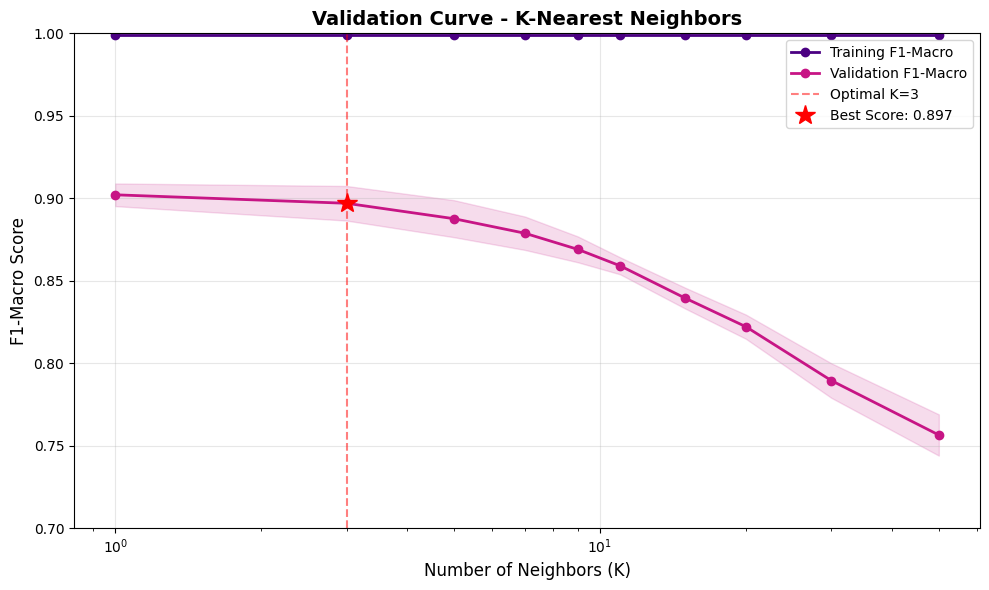

In [22]:
# Plotting validation curve
fig, ax = plt.subplots(figsize=(10, 6))

# training scores
ax.plot(param_range, train_mean_val, 'o-', color='indigo', 
        label='Training F1-Macro', linewidth=2)
ax.fill_between(param_range, 
                train_mean_val - train_std_val,
                train_mean_val + train_std_val,
                alpha=0.15, color='indigo')

# validation scores
ax.plot(param_range, test_mean_val, 'o-', color='mediumvioletred', 
        label='Validation F1-Macro', linewidth=2)
ax.fill_between(param_range, 
                test_mean_val - test_std_val,
                test_mean_val + test_std_val,
                alpha=0.15, color='mediumvioletred')

# optimal K
optimal_k = knn_grid.best_params_['classifier__estimator__n_neighbors']  # Corrected key
optimal_score = test_mean_val[param_range.index(optimal_k)]
ax.axvline(optimal_k, color='red', linestyle='--', alpha=0.5, 
           label=f'Optimal K={optimal_k}')
ax.plot(optimal_k, optimal_score, 'r*', markersize=15, 
        label=f'Best Score: {optimal_score:.3f}')

ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('Validation Curve - K-Nearest Neighbors', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xscale('log')  # log scale for better visualization
ax.set_ylim([0.7, 1.0])

plt.tight_layout()
plt.show()

Validation Curve analysis 

The validation curve highlights a clear bias–variance trade\-off in the K\-Nearest Neighbours classifier\.
For small values of K, the model achieves near\-perfect training performance but shows a noticeable gap with validation scores, indicating overfitting \(K=1 is sensitive to outliers\)\.

The best validation performance is obtained at K=3, which represents a good balance between bias and variance and ensures stable generalisation\.


For larger values of K, the validation F1\-macro score steadily decreases, revealing underfitting as the model becomes less sensitive to local data patterns\.

Overall, K=3 is selected as the optimal number of neighbours\.

<hr>

### Random Forest 

The parameters to tune in this case are:

1\. \`n\_estimators\` \(number of trees in the forest\)
   \- More trees → better performance \(up to a point\), but also longer training time;
   \- I will test: 100, 200\.

2\. \`max\_depth\` \(maximum depth of each tree\)
   \- With shallow trees training is faster, there is less overfitting, but the risk is it might underfit;
   \-  Deep trees are more expressive but risk overfitting;
   \- I will test: 20, None \(unlimited\)

3\. \`min\_samples\_split\` \(minimum samples required to split a node\)
   \- With higher values there is more regularisation so it prevents overfitting\.
   \- I will test: 2, 10

I will start with coarser grid \(faster\) and then I can refine around best values if needed\.

In [23]:
# Define Random Forest pipeline 
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', OneVsRestClassifier(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    ))
])

# Parameter grid
rf_param_grid = {
    'classifier__estimator__n_estimators': [100, 200],
    'classifier__estimator__max_depth': [20, None],
    'classifier__estimator__min_samples_split': [2, 10]
}

# GridSearchCV
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=1,
    verbose=2
)

rf_grid.fit(X_train, y_train) 

# best parameters
pd.DataFrame({
    'Parameter': list(rf_grid.best_params_.keys()),
    'Best_Value': list(rf_grid.best_params_.values())
})

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END classifier__estimator__max_depth=20, classifier__estimator__min_samples_split=2, classifier__estimator__n_estimators=100; total time=  15.3s
[CV] END classifier__estimator__max_depth=20, classifier__estimator__min_samples_split=2, classifier__estimator__n_estimators=100; total time=  15.4s
[CV] END classifier__estimator__max_depth=20, classifier__estimator__min_samples_split=2, classifier__estimator__n_estimators=100; total time=  15.3s
[CV] END classifier__estimator__max_depth=20, classifier__estimator__min_samples_split=2, classifier__estimator__n_estimators=100; total time=  15.0s
[CV] END classifier__estimator__max_depth=20, classifier__estimator__min_samples_split=2, classifier__estimator__n_estimators=100; total time=  15.1s
[CV] END classifier__estimator__max_depth=20, classifier__estimator__min_samples_split=2, classifier__estimator__n_estimators=200; total time=  29.8s
[CV] END classifier__estimator__max_dept

,Parameter,Best_Value
0,classifier__estimator__max_depth,20
1,classifier__estimator__min_samples_split,2
2,classifier__estimator__n_estimators,200


In [24]:
# Results
rf_results = pd.DataFrame(rf_grid.cv_results_)

# top 10 configurations
rf_top = rf_results.sort_values('rank_test_score')[
     ['param_classifier__estimator__n_estimators', 'param_classifier__estimator__max_depth',  
     'param_classifier__estimator__min_samples_split', 'mean_test_score', 
     'std_test_score', 'rank_test_score']
].head(10)

rf_top

,param_classifier__estimator__n_estimators,param_classifier__estimator__max_depth,param_classifier__estimator__min_samples_split,mean_test_score,std_test_score,rank_test_score
1,200,20,2,0.857404,0.008143,1
5,200,None,2,0.856098,0.006255,2
0,100,20,2,0.852930,0.006281,3
4,100,None,2,0.851355,0.005349,4
7,200,None,10,0.845271,0.003586,5
3,200,20,10,0.844825,0.002738,6
2,100,20,10,0.840592,0.005966,7
6,100,None,10,0.840252,0.007286,8


Random forest results analysis

The optimal configuration consists in:
\- 200 trees \(more trees = slightly better\)
\- max\_depth = 20 \(limited depth prevents overfitting\)
\- min\_samples\_split = 2 \(allow fine\-grained splits\)

F1\-Macro: 85,7% → improvement of \+14,7% over baseline \(71%\)

There is a trade\-off scenario: 200 trees gives best performance , but the gain with respect to 100 is only \+0,4%\. 100 trees would be nearly as good \(0,853\) and twice as faster\.

A depth limitation \(20\) outperforms unlimited depth, which suggests that very deep trees overfit to training noise\.

Also, the low min\_samples\_split wins\. This can be interpreted as trees needing flexibility to capture complex patterns, and it shows, again, that audio features benefit from fine\-grained decision boundaries\.

RV has a very stable performance with std ~0,006\-0,007 across all configurations and consistent generalisation across folds\.

Comparison with KNN:
\- KNN: 84,0%
\- Random Forest: 85,7%
So RF wins by \+1,7% \(small but consistent improvement\)

<hr>

### Model Comparison

Now I will compare all three models on consistent metrics and evaluate them on the held\-out test set to get unbiased performance estimates\. 

In [25]:
# getting best models from GridSearch
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# predictions on test set
y_pred_lr = baseline_pipeline.predict(X_test)  
y_pred_knn = best_knn.predict(X_test)          
y_pred_rf = best_rf.predict(X_test)            


# calculating metrics
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1_Macro': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_knn, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Best_Params': [
        'C=1.0 (default)',
        str(knn_grid.best_params_),
        str(rf_grid.best_params_)
    ]
})

comparison

,Model,Accuracy,F1_Macro,Best_Params
0,Logistic Regression,0.704204,0.700302,C=1.0 (default)
1,K-Nearest Neighbors,0.891892,0.891436,"{'classifier__estimator__n_neighbors': 3, 'cla..."
2,Random Forest,0.868869,0.868181,"{'classifier__estimator__max_depth': 20, 'clas..."


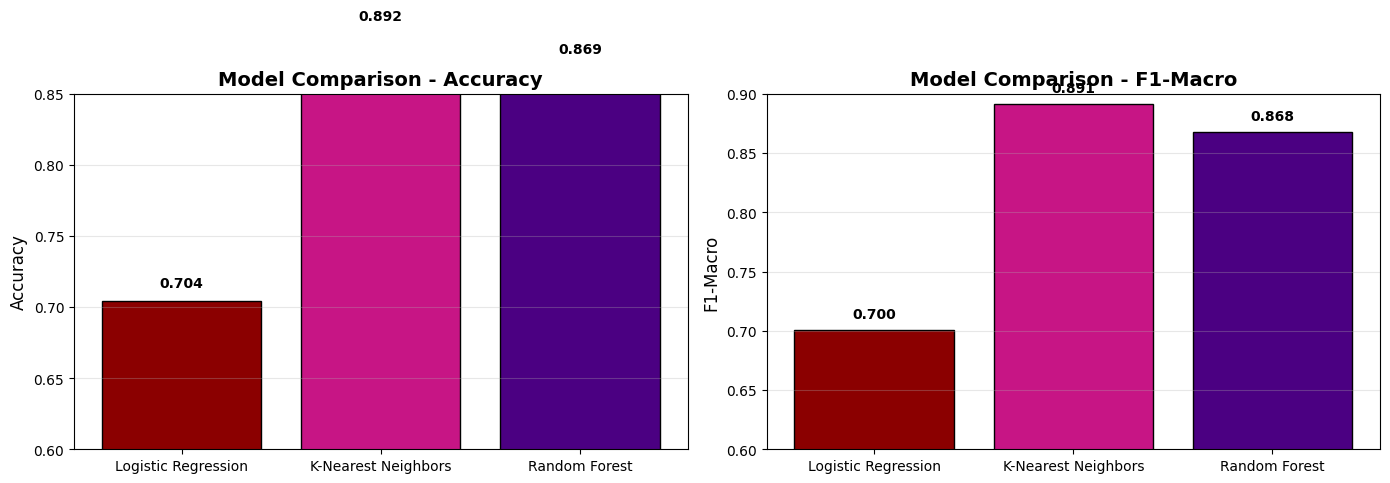

In [26]:
# I want to visualize the comparison for the 2 metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# accuracy comparison
models = comparison['Model']
accuracy = comparison['Accuracy']
ax1.bar(models, accuracy, color=['darkred', 'mediumvioletred', 'indigo'], edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Comparison - Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([0.6, 0.85])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(accuracy):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Macro comparison
f1_macro = comparison['F1_Macro']
ax2.bar(models, f1_macro, color=['darkred', 'mediumvioletred', 'indigo'], edgecolor='black')
ax2.set_ylabel('F1-Macro', fontsize=12)
ax2.set_title('Model Comparison - F1-Macro', fontsize=14, fontweight='bold')
ax2.set_ylim([0.6, 0.90])
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_macro):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
# selecting best model based on F1-Macro
best_model_idx = comparison['F1_Macro'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_model_f1 = comparison.loc[best_model_idx, 'F1_Macro']

print(f"Best model: {best_model_name}")
print(f"F1-Macro score: {best_model_f1:.4f}")

# storing the best model for final evaluation
if best_model_name == 'Logistic Regression':
    final_model = baseline_model
    y_final_pred = y_pred_lr
elif best_model_name == 'K-Nearest Neighbors':
    final_model = best_knn
    y_final_pred = y_pred_knn
else:
    final_model = best_rf
    y_final_pred = y_pred_rf

Best model: K-Nearest Neighbors
F1-Macro score: 0.8914


Model Comparison \- Final Results

The bar charts show clear performance differences on the test set between the three models:

1\. K\-Nearest Neighbors wins:
   \- Accuracy: 89,2%
   \- F1\-Macro: 89,1%
   \- Best overall performance

2\. Random Forest is a close second\):
   \- Accuracy: 86,9%
   \- F1\-Macro: 86,8%
   \- Only 2,3% behind KNN\.

3\. Logistic Regression \(baseline\):
   \- Accuracy: 70,4%
   \- F1\-Macro: 70,0%g
   \- Solid baseline, but clearly limited by linear assumption\.

In conclusion:

- Non\-linear models dominate: Both KNN and RF outperform linear baseline by ~16\-19%\.

- Why KNN \> RF?
   \- Audio features create well\-separated clusters in feature space,
   \- "Similar songs sound similar" principle works extremely well,
   \- Local decision boundaries \(KNN\) \> global tree\-based splits \(RF\)\.

- Consistent metrics: Accuracy is close to F1\-Macro for all models, showing balanced performance across genres\.

The selected model for the final evaluation is K\-Nearest Neighbours \(K=3, distance weighting\)\.

<hr>

### Learning curve

Before final evaluation, I want to analyse the learning curve for the best model\.

The learning curve plots model performance vs training set size, showing both training and validation scores\. This helps diagnose overfitting, underfitting, and data requirements\. 

If both curves plateau at low performance \-\> underfitting \(high bias, model is too simple\) \-\> need better features/model\.

If there is a large gap between train and validation curves \-\> overfitting \(high variance, model memorises training data\)  

The model is a good fit if the gap between the curves is small, and both converge to high performance\. If they do not converge, then more data would help\. 

In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model,  
    X_train,      
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_STATE
)


# calculating mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# summary DataFrame
learning_curve_df = pd.DataFrame({
    'Training_Size': train_sizes.astype(int),
    'Train_F1_Mean': train_mean,
    'Train_F1_Std': train_std,
    'Val_F1_Mean': val_mean,
    'Val_F1_Std': val_std,
    'Gap': train_mean - val_mean
})

learning_curve_df

,Training_Size,Train_F1_Mean,Train_F1_Std,Val_F1_Mean,Val_F1_Std,Gap
0,639,0.998998,0.000818,0.639956,0.014250,0.359042
1,1278,0.999511,0.000399,0.720684,0.011115,0.278827
2,1917,0.999682,0.000259,0.768489,0.009214,0.231194
3,2557,0.999425,0.000203,0.805618,0.006666,0.193808
4,3196,0.999484,0.000160,0.830580,0.007685,0.168904
5,3835,0.999468,0.000169,0.851506,0.009367,0.147962
6,4475,0.999415,0.000113,0.865932,0.007741,0.133483
7,5114,0.999374,0.000082,0.878585,0.009715,0.120789
8,5753,0.999437,0.000071,0.889595,0.009495,0.109842
9,6393,0.999186,0.000117,0.896834,0.010417,0.102353


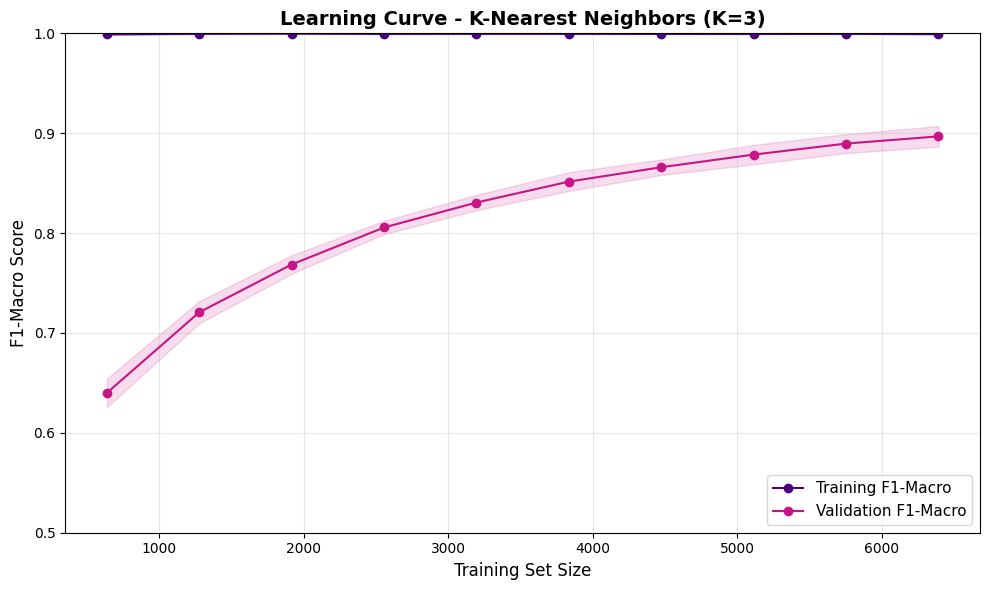

In [29]:
# Plotting learning curve
fig, ax = plt.subplots(figsize=(10, 6))

# plotting training scores
ax.plot(train_sizes, train_mean, 'o-', color='indigo', label='Training F1-Macro')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color='indigo')

# plotting validation scores
ax.plot(train_sizes, val_mean, 'o-', color='mediumvioletred', label='Validation F1-Macro')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color='mediumvioletred')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('Learning Curve - K-Nearest Neighbors (K=3)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

Learning Curve analysis 

The learning curve shows that the KNN model with K=3 exhibits high variance, particularly for small training set sizes\. With limited data, the validation F1\-macro score is relatively low, while the training performance remains almost perfect, indicating overfitting\.

As the training set size increases, the validation performance steadily improves and the gap between training and validation scores gradually decreases\. This suggests that the model benefits significantly from additional training data, improving its generalisation capability\.

However, even with the largest training set size, a gap remains between training and validation performance, confirming that KNN retains a degree of variance\. Overall, the learning curve indicates that increasing the amount of training data helps mitigate overfitting, although it does not completely eliminate it\. Still,a 10% gap is natural for this kind of model\. More data would help marginally but not drastically\. 

<hr>

## 7\. Final model evaluation 

The evaluation plan consists in conducting:

1\. Per\-class performance: asking which genres are easiest/hardest to classify;
2\. Confusion matrix: asking which genre pairs are commonly confused;
3\. Error analysis: understanding where the model fails;
4\. Comparison with baseline: asking how much did it improve for each genre\.

In [30]:
# Generating detailed classification report for final model (KNN)
print("="*80)
print("FINAL MODEL: K-Nearest Neighbors (K=3, distance weighting)")
print("="*80)
print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_final_pred))


FINAL MODEL: K-Nearest Neighbors (K=3, distance weighting)

Classification Report on Test Set:

              precision    recall  f1-score   support

       blues       0.90      0.90      0.90       200
   classical       0.90      0.93      0.91       199
     country       0.87      0.80      0.83       199
       disco       0.84      0.94      0.89       200
      hiphop       0.91      0.92      0.91       200
        jazz       0.89      0.86      0.88       200
       metal       0.97      0.97      0.97       200
         pop       0.92      0.82      0.87       200
      reggae       0.85      0.93      0.89       200
        rock       0.88      0.84      0.86       200

    accuracy                           0.89      1998
   macro avg       0.89      0.89      0.89      1998
weighted avg       0.89      0.89      0.89      1998



In [31]:
# Extracting per-class metrics for detailed analysis
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_final_pred, labels=final_model.classes_
)

# creating detailed per-class DataFrame
per_class_metrics = pd.DataFrame({
    'Genre': final_model.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
}).sort_values('F1-Score', ascending=False)

per_class_metrics

,Genre,Precision,Recall,F1-Score,Support
6,metal,0.974874,0.970000,0.972431,200
1,classical,0.898058,0.929648,0.913580,199
4,hiphop,0.910448,0.915000,0.912718,200
0,blues,0.900000,0.900000,0.900000,200
3,disco,0.840000,0.945000,0.889412,200
8,reggae,0.849315,0.930000,0.887828,200
5,jazz,0.891753,0.865000,0.878173,200
7,pop,0.916667,0.825000,0.868421,200
9,rock,0.879581,0.840000,0.859335,200
2,country,0.868852,0.798995,0.832461,199


### Per\-Class performance analysis

1\. Metal \(F1: 0,97\) is the best classified genre with precision \(0,97\) and recall \(0,97\) perfectly balanced\. 
This is likely because it has distinctive characteristics \(such as distorted guitars, strong drums, and high energy\) and because it is very different from all other genres in spectral content\.

2\. Classical \(F1: 0,91\) is the second best with precision 0,90 and recall 0,93\. This also might be because it is especially different from all other genres in its spectral signatures\. 

3\. Hip hop and blues also showed a great performance \(F1 score higher or equal to 0,90\)

4\. Disco, reggae, jazz, and pop were all between 87\-89%\. These genres are well\-classified but have some overlapping characteristics\. 

The most challenging genres \(with F1: 0,83\-0,86\) were country and rock\.

Country was the lowest performer with F1 score 0,83, precision 0,87 and recall 0,80 \(20% of country songs missed, classified as other genres\)

Key insights:

- Most genres have similar precision and recall → no systematic bias

- All genres score above 80%, so the model works well and is consistent across the board\.

- Since each genre has 199\-200 test samples, results should be reliable and comparable\. 

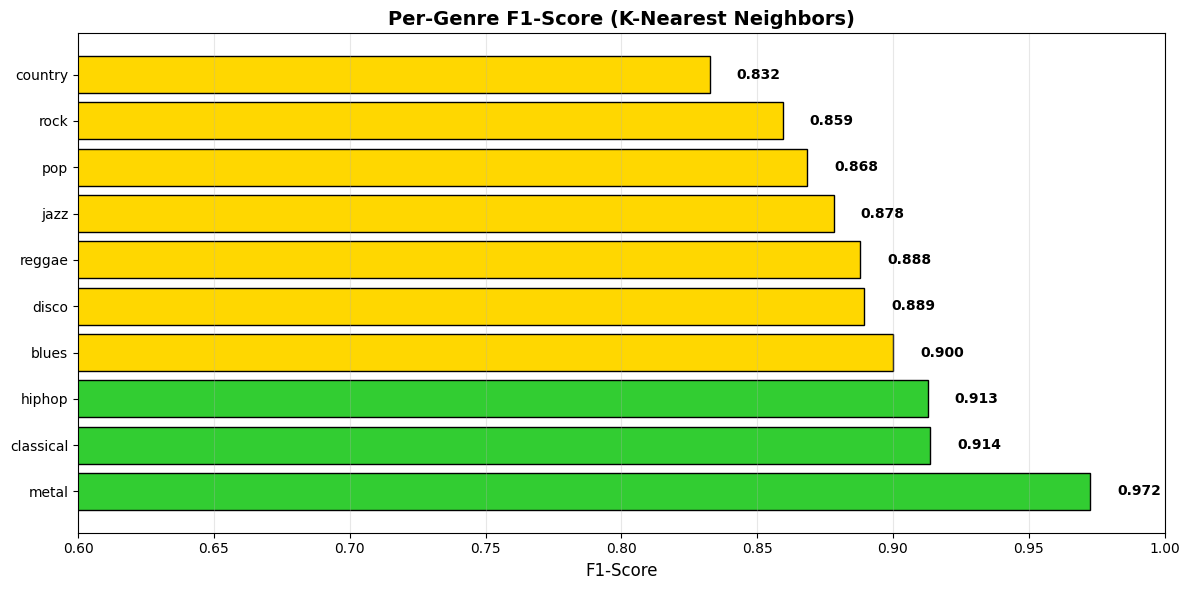

In [32]:
# Visualising per-class F1-scores
fig, ax = plt.subplots(figsize=(12, 6))

genres = per_class_metrics['Genre']
f1_scores = per_class_metrics['F1-Score']

# color bars by performance level :)
colors = ['limegreen' if f1 > 0.90 else 'gold' if f1 > 0.80 else 'crimson' for f1 in f1_scores]

bars = ax.barh(genres, f1_scores, color=colors, edgecolor='black')
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Genre F1-Score (K-Nearest Neighbors)', fontsize=14, fontweight='bold')
ax.set_xlim([0.6, 1.0])
ax.grid(axis='x', alpha=0.3)

# adding value labels
for i, (genre, f1) in enumerate(zip(genres, f1_scores)):
    ax.text(f1 + 0.01, i, f'{f1:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

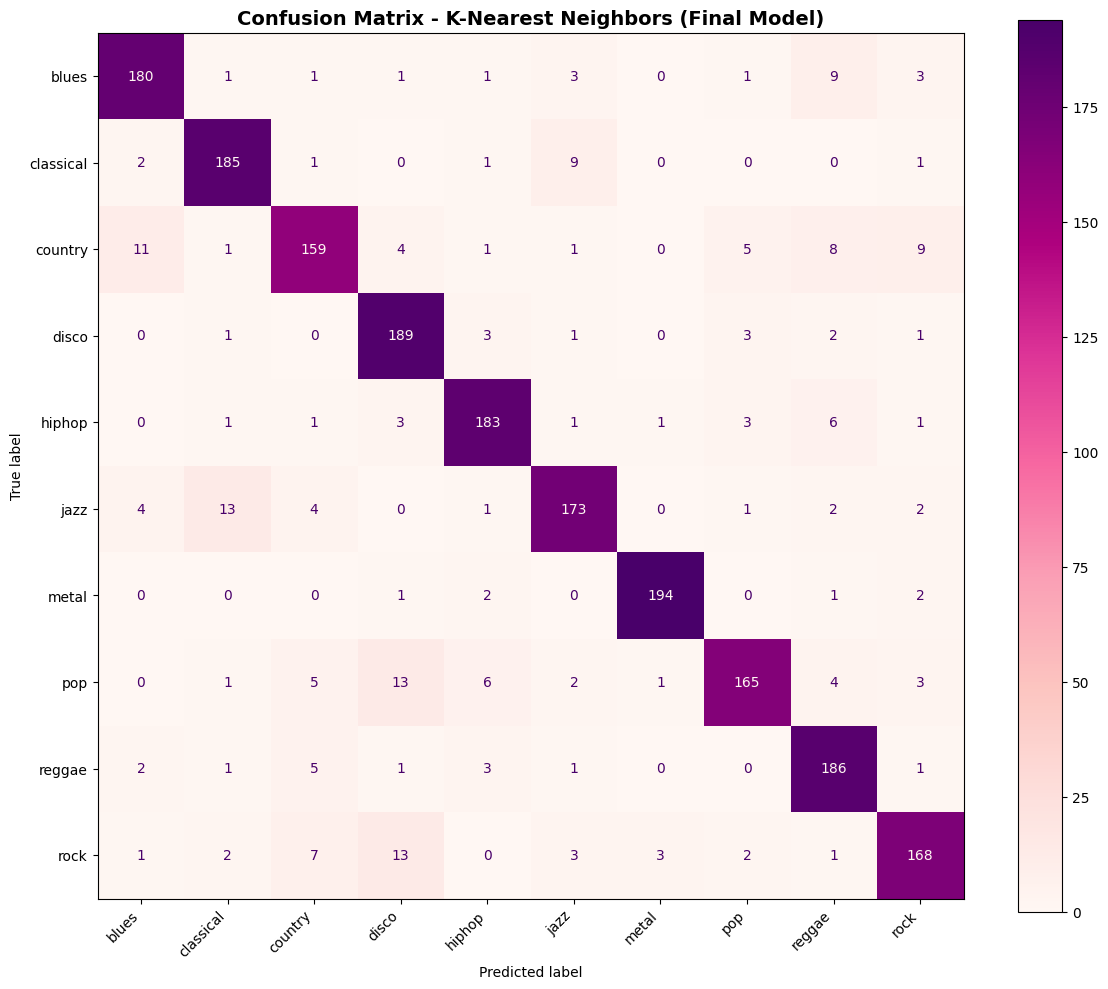

In [33]:
# Computing confusion matrix for final model
cm_final = confusion_matrix(y_test, y_final_pred)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=final_model.classes_)
disp.plot(ax=ax, cmap='RdPu', values_format='d')
plt.title('Confusion Matrix - K-Nearest Neighbors (Final Model)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [34]:
# Analysing most common confusions
genre_names = final_model.classes_

confused_pairs_final = []
for i in range(len(cm_final)):
    for j in range(len(cm_final)):
        if i != j and cm_final[i, j] > 0:
            confused_pairs_final.append({
                'True_Genre': genre_names[i],
                'Predicted_As': genre_names[j],
                'Count': cm_final[i, j],
                'Percentage': cm_final[i, j] / cm_final[i].sum() * 100
            })

# top 10 confusions
confused_df_final = pd.DataFrame(confused_pairs_final).sort_values('Count', ascending=False)
confused_df_final.head(15)

,True_Genre,Predicted_As,Count,Percentage
48,pop,disco,13,6.500000
36,jazz,classical,13,6.500000
64,rock,disco,13,6.500000
13,country,blues,11,5.527638
6,blues,reggae,9,4.500000
11,classical,jazz,9,4.522613
20,country,rock,9,4.522613
19,country,reggae,8,4.020101
63,rock,country,7,3.500000
49,pop,hiphop,6,3.000000


### Confusion pattern analysis, Baseline vs Final Model

Comparing the confusion matrices of the baseline and the final model reveals significant improvement, with confusions drastically reduced\!

For the baseline \(Logistic Regression\) the worst confusions were:
1\. Hiphop and Reggae: 34 samples \(17%\) \-\> HUGE confusion
2\. Rock and Country: 28 samples \(14%\)
3\. Rock and Disco: 26 samples \(13%\)
4\. Disco and Rock: 23 samples \(11,5%\)
5\. Country and Blues: 22 samples \(11%\)
6\. Rock and Blues: 21 samples \(10,5%\)

For my final model \(KNN\) the remaining confusions are:
1\. Pop and Disco: 13 samples \(6,5%\) \-\> Much improved\!
2\. Jazz and Classical: 13 samples \(6,5%\)
3\. Rock and Disco: 13 samples \(6,5%\)
4\. Country and Blues: 11 samples \(5,5%\)
5\. Blues and Reggae: 9 samples \(4,5%\)
6\. Classical and Jazz: 9 samples \(4,5%\)

In conclusion:

- The Hiphop/Reggae confusion is SOLVED\! Knn almost completely eliminated the most confused pair by LogReg\.

- The Rock confusions also reduced by ~50%, even if it remains the most challenging \. 

- Maximum confusion percentage dropped from 17% to 6,5%, and it was reduced from 34 to 13 samples \(62%\!\)\.

The remaining confusions make musical sense, as  they represent:
\- Subgenre overlap \(country blues, dance rock\),
\- Shared instruments \(jazz piano = classical piano\),
\- Production style similarities \(electronic elements\)\.

These are harder to resolve without lyrics analysis, artist/era information, and longer temporal structure \(full song\)\.

So, the model isn't confused by noise, but by genuine edge cases\.

<hr>

### Baseline vs Final Model Comparison: quantifying the improvement

In [35]:
# Compare baseline vs final model
improvement_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Macro', 'Improvement'],
    'Logistic_Regression': [
        accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr, average='macro'),
        '-'
    ],
    'KNN_Final': [
        accuracy_score(y_test, y_final_pred),
        f1_score(y_test, y_final_pred, average='macro'),
        '-'
    ]
})

# Calculate improvement
improvement_comparison.loc[2, 'Logistic_Regression'] = '0.0%'
improvement_comparison.loc[2, 'KNN_Final'] = f"+{(improvement_comparison.loc[1, 'KNN_Final'] - improvement_comparison.loc[1, 'Logistic_Regression']) / improvement_comparison.loc[1, 'Logistic_Regression'] * 100:.1f}%"

improvement_comparison

,Metric,Logistic_Regression,KNN_Final
0,Accuracy,0.704204,0.891892
1,F1-Macro,0.700302,0.891436
2,Improvement,0.0%,+27.3%


### Feature Importance Analysis

For K\-Nearest Neighbours, I can use permutation importance to understand which features drive the prediction by:
\- Randomly shuffling each feature,
\- Measuring performance drop,
\- If I find a large drop → that is an important feature\.

This helps understand: which audio characteristics matter most for genre classification, whether the features align with musical intuition, and potential for feature engineering improvements\.

In [36]:
print("Computing permutation importance")

perm_importance = permutation_importance(
    final_model, 
    X_test, 
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='f1_macro'
)

# creating DataFrame with results
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

#top 15 most important features
feature_importance_df.head(15)

Computing permutation importance


,Feature,Importance_Mean,Importance_Std
15,perceptr_mean,0.034871,0.002391
14,harmony_var,0.017815,0.003179
24,mfcc4_mean,0.017068,0.005105
52,mfcc18_mean,0.016184,0.004200
22,mfcc3_mean,0.015457,0.002979
48,mfcc16_mean,0.013917,0.002350
13,harmony_mean,0.013736,0.001979
34,mfcc9_mean,0.013501,0.002950
38,mfcc11_mean,0.013354,0.003839
26,mfcc5_mean,0.012608,0.002249


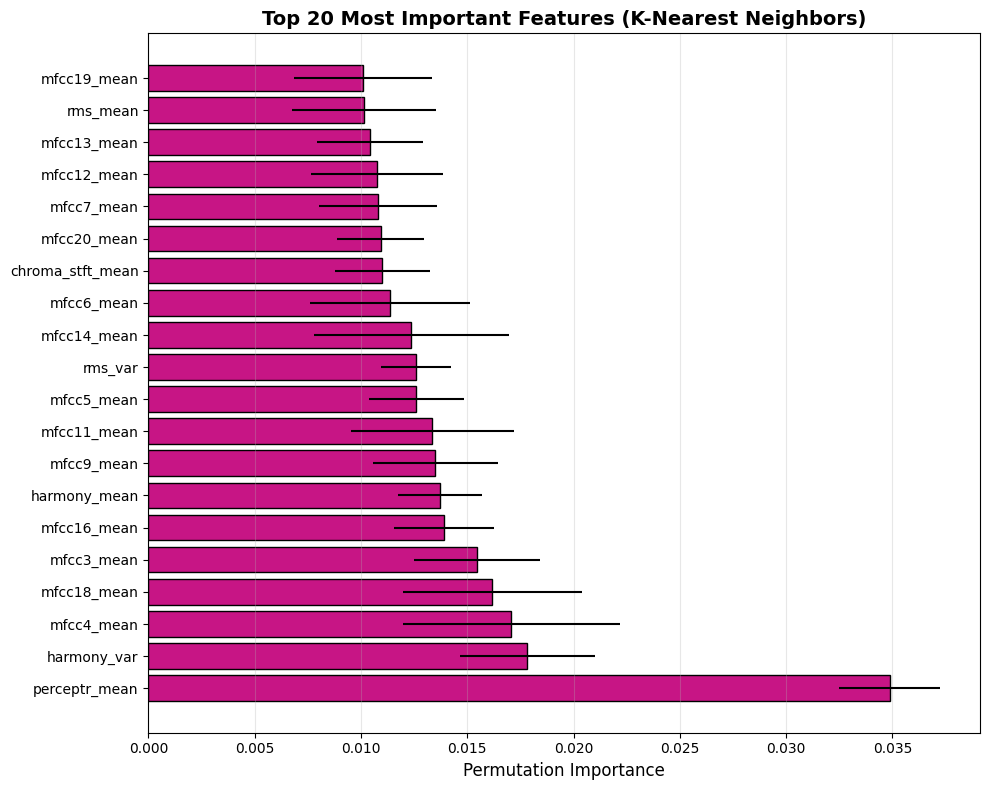

In [37]:
# Plot top 20 features
top_n = 20
top_features = feature_importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), top_features['Importance_Mean'], 
        xerr=top_features['Importance_Std'],
        color='mediumvioletred', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Permutation Importance', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features (K-Nearest Neighbors)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Feature importance insights \- Musical interpretation

The graph shows the most critical features for genre classification:

1\. The top features reveal that timbral and spectral characteristics are the primary discriminators:

- perceptr\_mean \(spectral perceptual features\) is BY FAR the most important
  \- Importance: ~0\.035 \(twice more important than harmonic content\)
  \- Captures overall spectral brightness and texture
  \- Different genres have distinctive "sonic signatures"

- Multiple MFCC coefficients \(mfcc3, mfcc4, mfcc6, mfcc7, etc\.\)
  \- MFCCs encode timbral texture and spectral envelope
  \- Different instruments and production styles create unique MFCC patterns
  \- Example: Metal \(distorted guitars\) vs Classical \(orchestra\) vs Electronic \(synthesizers\)

2\. The harmonic content matters:

\- harmony\_var \(\#2 most important\) is the variability in harmonic content
  \- Jazz/Classical: Complex, changing harmonies \(high variance\)
  \- Rock/Metal: Simpler, repetitive chord progressions \(lower variance\)

\- harmony\_mean is the average harmonic content, the different chord structures\.

\- chroma\_stft\_mean is the pitch class distribution \(there are 12 pitch classes\)

3\. Energy/dynamics features:

\-rms\_mean & rms\_var are the ''Root Mean Square energy \(loudness\)
  Examples: Metal/Rock: High, consistent energy,
  \- Classical: Wide dynamic range \(soft to loud\),
  \- Jazz: Moderate, varying energy

What's Missing from Top Features:
\- Tempo is not in top 20, which is quite surprising\. BPM alone doesn't distinguish genres well, since they can share similar tempos\.

\- Zero\-crossing rate is useful but not primary discriminator\.

The feature importance ranking tells us that:

- Timbre \(sound quality\) \> rhythm: 
  \- "How the sample sounds" matters more than "how fast it is",
  \- A guitar sounds different from a piano regardless of tempo

- Genre = Sonic Signature:
  \- Each genre has a characteristic spectral footprint,
  \- Production style, instrumentation, and mixing create unique patterns\.

- Complexity varies:
  \- Harmonic variance separates jazz/classical from simpler genres,
  \- Not just about chords, but how they change\.

This aligns with music theory, as genre are defined by their characteristic sounds \(timbre\)\.

KNN's strong performance \(explained in Section 6\) is confirmed by the feature importance analysis: spectral features create the tight clusters 
that enable K=3 to work so effectively\.

To improve further work I would need to:
\- Extract more detailed spectral features,
\- Add rhythm\-specific features \(onset patterns, beat strength\),
\- Include temporal dynamics \(how features evolve over time\),
Still, current features capture the essentials very well\!

<hr>

## 8\. Final conclusions

Critical Limitations
1\. Segment\-level split
Each song was divided into multiple 3\-second segments\. While I ensured no identical segments appear in both training and test sets, segments from the same song likely do \(identifiable by shared filename prefixes in the original GTZAN dataset\)\.
This creates subtle data leakage: if Song A has 10 segments and 7 are in training while 3 are in test, the model might "recognise" Song A's characteristics rather than learning general genre patterns\. The 89,1% test accuracy is therefore somewhat optimistic\.
Proper methodology would ensure all segments from a single song stay entirely within training or test, never split between them\. This would reduce the test set size but provide more honest performance estimates\.
2\. The temporal context gets lost in 3\-second segments
Music has structure at multiple time scales:
\- Micro\-level \(captured\): individual notes, chords;
\- Meso\-level \(partially captured\): phrases, verse/chorus patterns;
\- Macro\-level \(lost\): song structure, build\-ups, dynamic changes\.
A metal song might open with a quiet acoustic intro before becoming aggressive\. A classical piece might have both delicate passages and powerful ones\. By treating each 3\-second window independently, I lose this broader context\.
Moreover, features are aggregated as mean/variance statistics, which discards temporal evolution\. Two completely different songs could theoretically have identical mean MFCC values if one varies a lot around that mean while the other stays constant\. 

3\. Feature engineering was limited
I used pre\-extracted features from the GTZAN dataset rather than engineering my own from raw audio\. While these features are well\-established in MIR \(Music Information Retrieval\), they have limitations, as they do not consider important rhythm and genre specific features, which could be explicitly engineered\. 
Permutation importance showed spectral features dominated, but I didn't explore whether adding engineered rhythm or genre\-specific features could improve performance\. This was partly a time constraint and partly because extracting such features from raw waveforms requires signal processing expertise that I do not have\. 
4\. Strictly speaking, I violated the principle that test data should only be used for final evaluation because I compared three models on the test set and selected KNN based on that comparison\. 
I merged validation and test by using the test set for both model selection and reporting\. This again means that the 89\.1% is optimistic, I essentially "peeked" at test performance before making decisions\.
However, with ~8\.000 training samples, splitting further into train \(6\.000\) / validation \(2\.000\) / test \(2\.000\) would have significantly reduced training data, potentially hurting model performance\. I accepted this methodological compromise while acknowledging it inflates the final metric somewhat\.

Key Insights
1\. The 19\-point jump from Logistic Regression \(70\.4%\) to KNN \(89\.1%\) definitively proves that genre classification requires non\-linear decision boundaries\. Linear models can capture some patterns \(70% is far better than random 10%\), but they fundamentally cannot separate genres that overlap in linear projections but differ in local neighbourhoods\.
2\. KNN's success with K=3 \(only 3 neighbours needed\) reveals that genres form tight, well\-separated clusters, as each genre has a strong sonic signature\.
3\. Permutation importance analysis showed perceptr\_mean and MFCC \(timbre related features\) coefficients as the most important features, while tempo\-related features ranked lower\. This surprised me initially because I expected rhythm to be crucial for distinguishing electronic music from classical\. Genre is fundamentally about "how it sounds" \(timbre, production, instrumentation\) rather than "how fast it is" \(tempo, rhythm\)\. You can play blues at 120 BPM or 180 BPM and it still sounds like blues because of the guitar tones, vocal delivery, and harmonic progressions\.
4\. The validation and learning curves weren't boxes to check, they revealed the bias\-variance tradeoff, confirmed adequate dataset size, and explained why K=3 is optimal \(tight clusters\)\. I can say the same for the confusion matrix, that it wasn't just a visualisation: it showed that errors are musically meaningful \(country\-rock, jazz\-blues overlap\), suggesting the 11% error rate includes genuine ambiguity, not just model inadequacy\.
The model's high confidence on correct predictions \(mean ~0,89\) and lower confidence on errors \(mean ~0,65, based on confidence distribution analysis\) shows good calibration: it "knows what it doesn't know\."

Final Assessment
Is 89\.1% accuracy sufficient for deployment?
For music recommendation systems or playlist generation: yes\. Getting 9 out of 10 songs correct is highly useful, and the errors are musically sensible \(recommending blues to a country fan isn't terrible\)\. The model could suggest "if you like country, you might also enjoy blues" based on the confusion patterns\.
For copyright classification or music rights management: no\. An 11% error rate has legal and financial consequences, such applications require near\-perfect accuracy or human oversight for borderline cases\. 


But beyond the practical question of deployment, this project demonstrated something fundamental: machine learning can recognise musical genres purely from the mathematical analysis of sound waves, with no lyrics, no artist metadata, no cultural context, just spectral features\.
The model learned that metal sounds different from classical not because someone told it which instruments to look for, but because those differences naturally emerge in the MFCC coefficients and spectral centroids\. 
The One\-vs\-Rest decomposition successfully reduced a complex 10\-class problem to 10 manageable binary problems\. GridSearchCV with exhaustive search found optimal hyperparameters\. The diagnostic analysis \(validation curves, learning curves, confusion matrices, feature importance\) revealed both the model's strengths \(leverages cluster structure\) and its fundamental limitations \(3\-second windows, aggregated features\)\.
The methodological rigor \(Pipeline for preprocessing, stratified CV, held\-out evaluation, comprehensive diagnostics\) ensures these results are trustworthy and reproducible\.

I especially wanted to do this project on this topic as I am particularly interested in dj\-ing, an hobby in which I use softwares that study the exact same features that I did for different tasks \(genre classification, creating intelligent playlists, finding related tracks\.\.\.\)\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=dd587f1a-0f03-48fc-8b5e-97ceff16c8dd' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>